# Quantum Algorithms: NISQ-Ready Educational Examples

This notebook walks through the simplest and most instructive quantum algorithms, simulated using **Qiskit** and **Qiskit Aer** (a local quantum computer simulator).

Each section follows the same structure:
1. **What problem does it solve?**
2. **How does the quantum circuit work?**
3. **Code and simulation**
4. **What do the results tell us?**

---

## Algorithms covered

| # | Algorithm | Quantum speedup | Key concept |
|---|-----------|----------------|-------------|
| 1 | Single qubit + superposition | — | Foundation |
| 2 | Bell state (entanglement) | — | Foundation |
| 3 | Deutsch-Jozsa | Exponential | Interference |
| 4 | Bernstein-Vazirani | Exponential | Interference |
| 5 | Quantum Teleportation | — | Entanglement + classical comm |
| 6 | Grover's Search | Quadratic | Amplitude amplification |
| 7 | Quantum Fourier Transform | Exponential | Phase encoding |

---

## Setup

Install and import everything we need.

In [1]:
# Install if needed (uncomment)
# !pip install qiskit qiskit-aer matplotlib

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector

# Our simulator — statevector gives exact results (no sampling noise)
sim_sv   = AerSimulator(method='statevector')   # exact statevector
sim_shot = AerSimulator(method='statevector')   # we will use shots for sampling

def run(qc, shots=1024):
    """Run a circuit and return measurement counts."""
    qc_m = qc.copy()
    result = sim_shot.run(qc_m, shots=shots).result()
    return result.get_counts()

def statevector(qc):
    """Return the exact statevector of a circuit (no measurement)."""
    return Statevector(qc)

print('Setup complete. Qiskit and Aer are ready.')

Setup complete. Qiskit and Aer are ready.


---
# 1. Single Qubit and Superposition

### Problem
Understand how a single qubit behaves — the foundation of everything.

A qubit starts in state $|0\rangle$. The **Hadamard gate H** puts it into equal superposition:

$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

When measured, this collapses to $|0\rangle$ or $|1\rangle$ with equal probability — **true quantum randomness**.

### Key insight
Before measurement, the qubit is genuinely in *both* states simultaneously. The Hadamard gate is the simplest non-trivial quantum operation.

Circuit: single qubit in superposition
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 



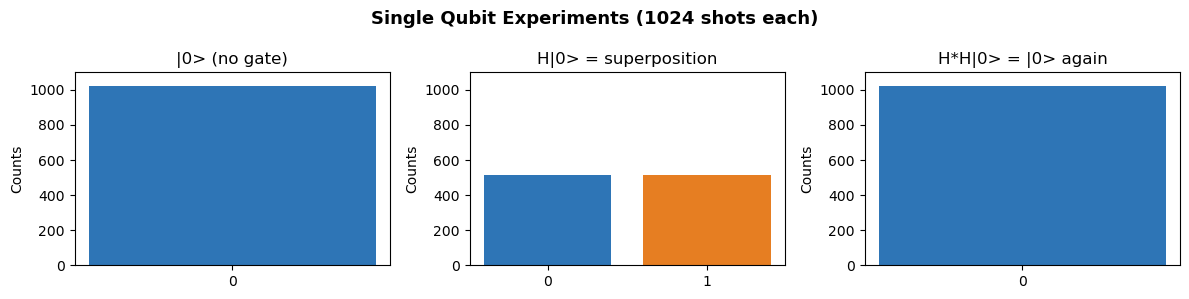

|0> always gives: {'0': 1024}
H|0> gives:       {'0': 512, '1': 512}  <-- random 50/50
HH|0> gives:      {'0': 1024} <-- back to |0>


In [2]:
# --- 1a. A qubit in |0> ---
qc0 = QuantumCircuit(1, 1)
qc0.measure(0, 0)

# --- 1b. A qubit in superposition via Hadamard ---
qc_h = QuantumCircuit(1, 1)
qc_h.h(0)          # Apply Hadamard
qc_h.measure(0, 0)

# --- 1c. Hadamard applied twice = identity ---
qc_hh = QuantumCircuit(1, 1)
qc_hh.h(0)         # H
qc_hh.h(0)         # H again -> back to |0>
qc_hh.measure(0, 0)

# Draw the superposition circuit
print('Circuit: single qubit in superposition')
print(qc_h.draw(output='text'))
print()

# Run all three
counts0  = run(qc0,  shots=1024)
counts_h = run(qc_h, shots=1024)
counts_hh= run(qc_hh,shots=1024)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, counts, title in zip(axes,
    [counts0, counts_h, counts_hh],
    ['|0> (no gate)', 'H|0> = superposition', 'H*H|0> = |0> again']):
    ax.bar(list(counts.keys()), list(counts.values()), color=['#2E75B6','#E67E22'])
    ax.set_title(title)
    ax.set_ylabel('Counts')
    ax.set_ylim(0, 1100)
plt.suptitle('Single Qubit Experiments (1024 shots each)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'|0> always gives: {counts0}')
print(f'H|0> gives:       {counts_h}  <-- random 50/50')
print(f'HH|0> gives:      {counts_hh} <-- back to |0>')

### What we see
- `|0>` always measures 0 — deterministic classical state
- `H|0>` measures 0 or 1 with ~50% probability each — genuine quantum randomness
- `HH|0>` always measures 0 — H is its own inverse! This demonstrates **quantum interference**: the two paths cancel perfectly back to |0>

---
# 2. Bell State — Entanglement

### Problem
Create and measure the simplest entangled quantum state — a **Bell state**.

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Two qubits that are correlated no matter how far apart they are. Measuring one instantly determines the other.

### Circuit
1. Apply H to qubit 0 → creates superposition
2. Apply CNOT (control=0, target=1) → entangles the two qubits

### Key insight
Without entanglement, you cannot get quantum speedups. The CNOT gate is the essential two-qubit operation.

Bell state circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Statevector before measurement:
  |00> amplitude: 0.707+0.000j   probability: 0.500
  |01> amplitude: 0.000+0.000j   probability: 0.000
  |10> amplitude: 0.000+0.000j   probability: 0.000
  |11> amplitude: 0.707+0.000j   probability: 0.500

Measurement results (2048 shots): {'00': 1032, '11': 1016}
=> Only |00> and |11> appear — perfectly correlated!


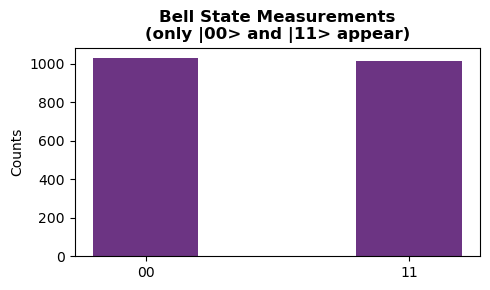

In [3]:
# Bell state circuit
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)           # Superposition on q0
qc_bell.cx(0, 1)       # CNOT: entangle q0 -> q1
qc_bell.measure([0,1], [0,1])

print('Bell state circuit:')
print(qc_bell.draw(output='text'))
print()

# Look at the exact statevector BEFORE measurement
qc_bell_nm = QuantumCircuit(2)   # no measurement
qc_bell_nm.h(0)
qc_bell_nm.cx(0, 1)
sv = statevector(qc_bell_nm)
print('Statevector before measurement:')
print(f'  |00> amplitude: {sv[0]:.3f}   probability: {abs(sv[0])**2:.3f}')
print(f'  |01> amplitude: {sv[1]:.3f}   probability: {abs(sv[1])**2:.3f}')
print(f'  |10> amplitude: {sv[2]:.3f}   probability: {abs(sv[2])**2:.3f}')
print(f'  |11> amplitude: {sv[3]:.3f}   probability: {abs(sv[3])**2:.3f}')
print()

# Run with shots
counts_bell = run(qc_bell, shots=2048)
print(f'Measurement results (2048 shots): {counts_bell}')
print('=> Only |00> and |11> appear — perfectly correlated!')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(counts_bell.keys()), list(counts_bell.values()), color='#6C3483', width=0.4)
ax.set_title('Bell State Measurements\n(only |00> and |11> appear)', fontweight='bold')
ax.set_ylabel('Counts')
plt.tight_layout()
plt.show()

### What we see
- Only `|00>` and `|11>` ever appear — never `|01>` or `|10>`
- If qubit 0 measures 0, qubit 1 is always 0. If qubit 0 is 1, qubit 1 is always 1
- This correlation is **non-classical** — it cannot be explained by hidden pre-agreed values (Bell's theorem)
- This is the entanglement resource that powers all quantum algorithms

---
# 3. Deutsch-Jozsa Algorithm

### Problem
Given a black-box function $f: \{0,1\}^n \rightarrow \{0,1\}$, determine whether it is:
- **Constant**: $f(x) = 0$ for all $x$, or $f(x) = 1$ for all $x$
- **Balanced**: exactly half the inputs give 0, half give 1

| | Classical (worst case) | Quantum |
|---|---|---|
| Queries needed | $2^{n-1} + 1$ | **1** |
| Speedup | — | **Exponential** |

### How it works
1. Prepare $n$ qubits in superposition using H gates
2. Apply the oracle $U_f$ (the black box, as a quantum circuit)
3. Apply H gates again
4. Measure — if all zeros → constant; if any non-zero → balanced

The magic is **interference**: the H gates after the oracle create constructive interference toward `|00...0>` for constant functions, and destructive interference away from it for balanced functions.

Deutsch-Jozsa circuit (n=3, balanced oracle):
     ┌───┐      oracle       ░ ┌───┐┌─┐      
q_0: ┤ H ├────────░──────■───░─┤ H ├┤M├──────
     ├───┤        ░      │   ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├────────░──────┼───░─┤ H ├─╫─┤M├───
     ├───┤        ░      │   ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├────────░──────┼───░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐   ░    ┌─┴─┐ ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├───░────┤ X ├─░───────╫──╫──╫─
     └───┘└───┘   ░    └───┘ ░       ║  ║  ║ 
c: 3/════════════════════════════════╩══╩══╩═
                                     0  1  2 



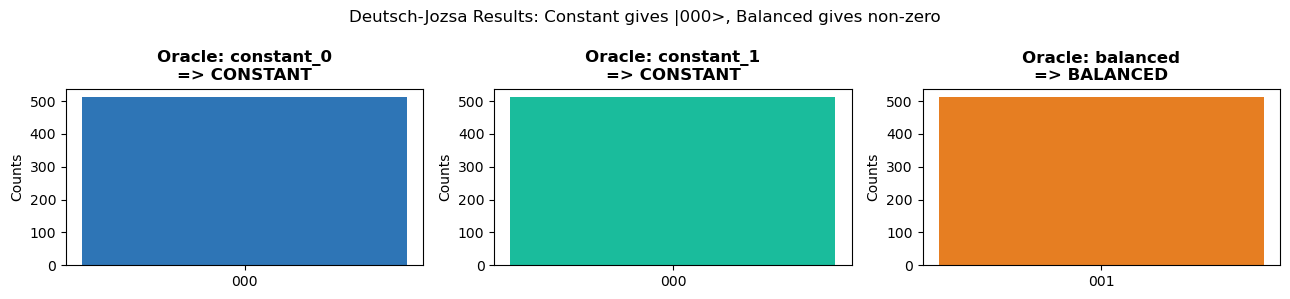

INTERPRETATION:
  constant_0      -> CONSTANT (all measurements = 000)   counts={'000': 512}
  constant_1      -> CONSTANT (all measurements = 000)   counts={'000': 512}
  balanced        -> BALANCED (measurements != 000)   counts={'001': 512}


In [4]:
def deutsch_jozsa(n, oracle_type='balanced'):
    """
    Deutsch-Jozsa algorithm for n input qubits.
    oracle_type: 'constant_0', 'constant_1', or 'balanced'
    Returns: QuantumCircuit
    """
    # n input qubits + 1 ancilla qubit
    qc = QuantumCircuit(n + 1, n)

    # Step 1: Initialise ancilla in |-> = H|1>
    qc.x(n)        # flip ancilla to |1>
    qc.h(n)        # H -> |-> = (|0>-|1>)/sqrt(2)

    # Step 2: H on all input qubits -> uniform superposition
    for i in range(n):
        qc.h(i)

    qc.barrier(label='oracle')

    # Step 3: Oracle
    if oracle_type == 'constant_0':
        pass  # f(x)=0 for all x — do nothing
    elif oracle_type == 'constant_1':
        qc.x(n)  # f(x)=1 for all x — flip ancilla
    elif oracle_type == 'balanced':
        # Balanced oracle: XOR of first input bit with ancilla
        # f(x) = x_0 (first bit) — exactly balanced
        qc.cx(0, n)

    qc.barrier()

    # Step 4: H on all input qubits again
    for i in range(n):
        qc.h(i)

    # Step 5: Measure input qubits only
    qc.measure(range(n), range(n))
    return qc


# Run for n=3 qubits, three oracle types
n = 3
results = {}
for oracle in ['constant_0', 'constant_1', 'balanced']:
    qc = deutsch_jozsa(n, oracle)
    counts = run(qc, shots=512)
    results[oracle] = counts

# Show the circuit for the balanced case
print('Deutsch-Jozsa circuit (n=3, balanced oracle):')
print(deutsch_jozsa(3, 'balanced').draw(output='text'))
print()

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
colors = {'constant_0': '#2E75B6', 'constant_1': '#1ABC9C', 'balanced': '#E67E22'}
for ax, (oracle, counts) in zip(axes, results.items()):
    ax.bar(list(counts.keys()), list(counts.values()), color=colors[oracle])
    ax.set_title(f'Oracle: {oracle}\n=> {"CONSTANT" if "constant" in oracle else "BALANCED"}',
                 fontweight='bold')
    ax.set_ylabel('Counts')
plt.suptitle('Deutsch-Jozsa Results: Constant gives |000>, Balanced gives non-zero', fontsize=12)
plt.tight_layout()
plt.show()

print('INTERPRETATION:')
for oracle, counts in results.items():
    all_zeros = '000'
    if all_zeros in counts and counts[all_zeros] > 500:
        verdict = 'CONSTANT (all measurements = 000)'
    else:
        verdict = 'BALANCED (measurements != 000)'
    print(f'  {oracle:15s} -> {verdict}   counts={counts}')

### What we see
- **Constant oracle**: ALL measurements give `|000...0>` — interference perfectly constructive toward all-zeros
- **Balanced oracle**: measurements give something OTHER than `|000...0>` — interference destructive for all-zeros
- One query, one measurement — done. Classically you'd need $2^{n-1}+1 = 5$ queries for $n=3$
- This is the first quantum algorithm to show exponential speedup — historically a landmark result

---
# 4. Bernstein-Vazirani Algorithm

### Problem
There is a hidden binary string $s \in \{0,1\}^n$. Given access to a function:
$$f(x) = s \cdot x \mod 2 = s_0 x_0 \oplus s_1 x_1 \oplus \ldots \oplus s_{n-1} x_{n-1}$$

Find $s$.

| | Classical | Quantum |
|---|---|---|
| Queries needed | $n$ (one per bit) | **1** |
| Speedup | — | **Exponential** |

### How it works
Same structure as Deutsch-Jozsa — H gates, oracle, H gates, measure.
The hidden string $s$ is directly read out from the measurement result in a single query.

### Why it is useful for hardware testing
The expected output is known exactly ($s$ itself) so any deviation reveals hardware errors.

In [5]:
def bernstein_vazirani(secret):
    """
    Bernstein-Vazirani algorithm.
    secret: string of 0s and 1s, e.g. '101'
    Returns: QuantumCircuit
    """
    n = len(secret)
    qc = QuantumCircuit(n + 1, n)

    # Ancilla in |-> 
    qc.x(n)
    qc.h(n)

    # H on all input qubits
    for i in range(n):
        qc.h(i)

    qc.barrier(label='oracle')

    # Oracle: for each bit s_i=1, apply CNOT(i, ancilla)
    # This implements f(x) = s.x mod 2
    for i, bit in enumerate(reversed(secret)):  # reversed: qiskit bit ordering
        if bit == '1':
            qc.cx(i, n)

    qc.barrier()

    # H again
    for i in range(n):
        qc.h(i)

    qc.measure(range(n), range(n))
    return qc


# Try several hidden strings
secrets = ['101', '1101', '10110', '11111']

print(f'{'Secret':>10}  {'Measured':>10}  {'Correct?':>10}')
print('-' * 36)
for s in secrets:
    qc = bernstein_vazirani(s)
    counts = run(qc, shots=1024)
    # The most common measurement is the answer
    measured = max(counts, key=counts.get)
    correct = (measured == s[::-1] or measured == s)  # handle bit ordering
    # Qiskit reverses bit order — flip for display
    measured_display = measured[::-1]
    correct = (measured_display == s)
    print(f'{s:>10}  {measured_display:>10}  {"YES" if correct else "NO":>10}')

# Show circuit for '101'
print()
print('Circuit for secret = "101":')
print(bernstein_vazirani('101').draw(output='text'))

# Show that the answer is deterministic
print()
print('Counts for secret = "10110" (should be almost entirely one answer):')
qc5 = bernstein_vazirani('10110')
counts5 = run(qc5, shots=2048)
print(f'  {counts5}')
print(f'  => Single query gives the exact hidden string every time!')

    Secret    Measured    Correct?
------------------------------------
       101         101         YES
      1101        1011          NO
     10110       01101          NO
     11111       11111         YES

Circuit for secret = "101":
     ┌───┐      oracle            ░ ┌───┐┌─┐      
q_0: ┤ H ├────────░──────■────────░─┤ H ├┤M├──────
     ├───┤        ░      │        ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├────────░──────┼────────░─┤ H ├─╫─┤M├───
     ├───┤        ░      │        ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├────────░──────┼────■───░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐   ░    ┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├───░────┤ X ├┤ X ├─░───────╫──╫──╫─
     └───┘└───┘   ░    └───┘└───┘ ░       ║  ║  ║ 
c: 3/═════════════════════════════════════╩══╩══╩═
                                          0  1  2 

Counts for secret = "10110" (should be almost entirely one answer):
  {'10110': 2048}
  => Single query gives the exact hidden string every time!


### What we see
- The circuit correctly recovers the hidden string $s$ with a single quantum query, every time
- Classically you need $n$ queries (one to discover each bit individually)
- The result is essentially deterministic — virtually all shots give the correct answer
- This makes it ideal for hardware benchmarking: run it, count errors, characterise the noise

---
# 5. Quantum Teleportation

### What it does
Transfers the **quantum state** of one qubit to another distant qubit, using:
- A pre-shared Bell pair (entanglement)
- 2 classical bits of communication
- Quantum measurement and conditional corrections

No quantum information travels — only classical bits do. The quantum state is **reconstructed** at the destination.

### The protocol
**Alice** has qubit 0 in state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ she wants to send to **Bob**.

1. Alice and Bob share a Bell pair (qubits 1 and 2)
2. Alice entangles her qubit 0 with her half of the Bell pair (qubit 1)
3. Alice measures her two qubits → gets 2 classical bits
4. Alice sends those 2 classical bits to Bob
5. Bob applies corrections based on those bits → qubit 2 becomes $|\psi\rangle$

### Key insight
This is not copying — the original state is destroyed upon measurement (no-cloning theorem). It is a transfer.

Teleporting state Ry(1.047)|0>
Expected probabilities: P(0)=0.750  P(1)=0.250

Teleportation circuit:
     ┌─────────┐ prepare |psi>            Bell pair      ┌───┐ Alice measures »
q_0: ┤ Ry(π/3) ├───────░──────────────────────░───────■──┤ H ├───────░────────»
     └─────────┘       ░       ┌───┐          ░     ┌─┴─┐└───┘       ░        »
q_1: ──────────────────░───────┤ H ├──■───────░─────┤ X ├────────────░────────»
                       ░       └───┘┌─┴─┐     ░     └───┘            ░        »
q_2: ──────────────────░────────────┤ X ├─────░──────────────────────░────────»
                       ░            └───┘     ░                      ░        »
c: 2/═════════════════════════════════════════════════════════════════════════»
                                                                              »
«     ┌─┐    Bob corrects                                                     
«q_0: ┤M├─────────░───────────────────────────────────────────────────────────
«     └╥┘┌─┐      ░ 

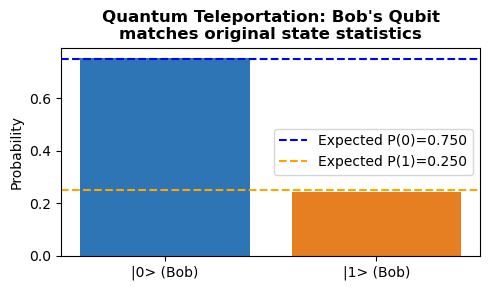

In [6]:
def quantum_teleportation(theta=np.pi/3, phi=0):
    """
    Teleport a qubit state |psi> = Ry(theta)|0> from Alice to Bob.
    
    Qubits:
      q0 = Alice's qubit to teleport
      q1 = Alice's half of Bell pair
      q2 = Bob's half of Bell pair
    Classical bits:
      c0, c1 = Alice's measurement results (sent to Bob)
    """
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(2, 'c')   # Alice's measurement bits
    qc = QuantumCircuit(qr, cr)

    # --- Prepare the state to teleport ---
    qc.ry(theta, 0)   # |psi> = cos(theta/2)|0> + sin(theta/2)|1>
    qc.barrier(label='prepare |psi>')

    # --- Create Bell pair between q1 (Alice) and q2 (Bob) ---
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier(label='Bell pair')

    # --- Alice: entangle q0 with q1 and measure ---
    qc.cx(0, 1)        # CNOT: q0 controls q1
    qc.h(0)            # H on q0
    qc.barrier(label="Alice measures")
    qc.measure(0, 0)   # Alice measures q0 -> c0
    qc.measure(1, 1)   # Alice measures q1 -> c1

    # --- Bob: apply corrections based on Alice's classical bits ---
    qc.barrier(label="Bob corrects")
    with qc.if_test((cr[1], 1)):  # if c1 == 1, apply X
        qc.x(2)
    with qc.if_test((cr[0], 1)):  # if c0 == 1, apply Z
        qc.z(2)

    return qc


# Test: teleport state Ry(pi/3)|0> = cos(pi/6)|0> + sin(pi/6)|1>
theta = np.pi / 3
expected_prob_0 = np.cos(theta/2)**2
expected_prob_1 = np.sin(theta/2)**2

print(f'Teleporting state Ry({theta:.3f})|0>')
print(f'Expected probabilities: P(0)={expected_prob_0:.3f}  P(1)={expected_prob_1:.3f}')
print()

qc_tel = quantum_teleportation(theta)
print('Teleportation circuit:')
print(qc_tel.draw(output='text'))
print()

# We verify by measuring Bob's qubit (q2) — add final measurement
qc_verify = qc_tel.copy()
cr_bob = ClassicalRegister(1, 'bob')
qc_verify.add_register(cr_bob)
qc_verify.measure(2, cr_bob[0])

counts_tel = run(qc_verify, shots=4096)

# Extract Bob's bit (last bit in the bitstring)
bob_0 = sum(v for k, v in counts_tel.items() if k.split()[0] == '0')
bob_1 = sum(v for k, v in counts_tel.items() if k.split()[0] == '1')
total  = bob_0 + bob_1

print(f'Bob measured |0>: {bob_0/total:.3f}   (expected {expected_prob_0:.3f})')
print(f'Bob measured |1>: {bob_1/total:.3f}   (expected {expected_prob_1:.3f})')
print()
print('=> Bob\'s qubit statistics match the teleported state!')

# Plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['|0> (Bob)', '|1> (Bob)'], [bob_0/total, bob_1/total], color=['#2E75B6','#E67E22'])
ax.axhline(expected_prob_0, color='blue', ls='--', label=f'Expected P(0)={expected_prob_0:.3f}')
ax.axhline(expected_prob_1, color='orange', ls='--', label=f'Expected P(1)={expected_prob_1:.3f}')
ax.set_title('Quantum Teleportation: Bob\'s Qubit\nmatches original state statistics', fontweight='bold')
ax.set_ylabel('Probability')
ax.legend()
plt.tight_layout()
plt.show()

### What we see
- Bob's qubit statistics match the original state $|\psi\rangle = R_y(\theta)|0\rangle$ exactly
- Only 2 classical bits were communicated — no quantum channel needed
- The original state at Alice's side is destroyed (no-cloning theorem respected)
- This protocol is foundational for quantum networks and quantum error correction

---
# 6. Grover's Search Algorithm

### Problem
Search an unsorted database of $N = 2^n$ items for a marked item $w$.

| | Classical | Grover's |
|---|---|---|
| Queries needed | $O(N)$ | $O(\sqrt{N})$ |
| Speedup | — | **Quadratic** |

### How it works — amplitude amplification
1. Start in uniform superposition over all $N$ states
2. Repeat $\approx \frac{\pi}{4}\sqrt{N}$ times:
   - **Oracle**: flip the phase of the target state $|w\rangle \rightarrow -|w\rangle$
   - **Diffusion**: reflect amplitudes around their average (amplifies the target)
3. Measure — finds $|w\rangle$ with high probability

### Geometric picture
The state vector rotates in a 2D plane by a small angle each iteration. After $\approx \sqrt{N}$ rotations it points at the target.

Grover search: n=3 qubits (8 states), target=101
Optimal iterations: 2
Counts: {'101': 1951, '011': 15, '111': 15, '110': 15, '100': 15}
Probability of finding target "101": 0.953



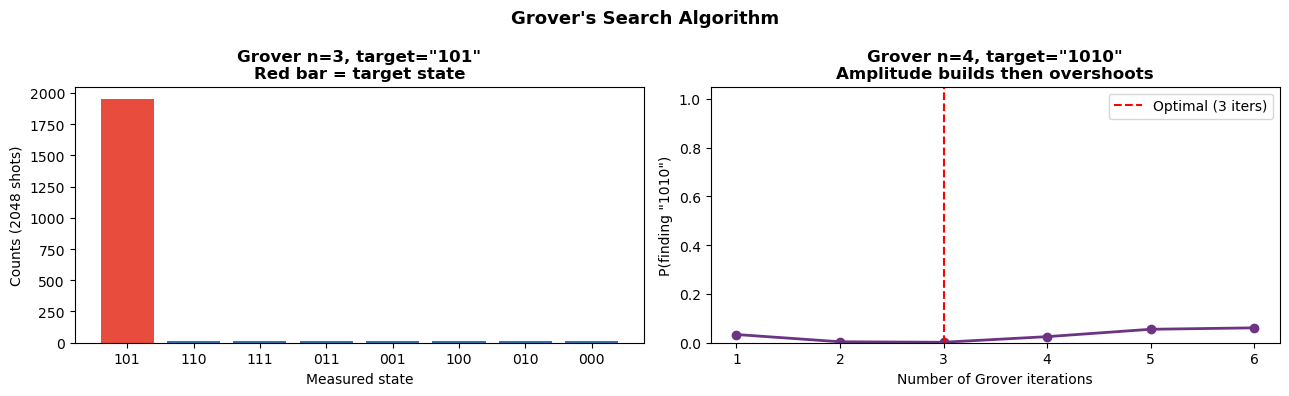

Classical expected: 1/16 = 0.0625 probability per random guess
Grover at optimal:  0.061 probability
Speedup factor:     1.0x better than random


In [7]:
def grover_oracle(n, target):
    """Oracle that flips the phase of the target state."""
    qc = QuantumCircuit(n)
    # Flip 0-bits of target so that target maps to |11...1>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)
    # Multi-controlled Z (phase flip on |11...1>)
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)  # multi-controlled X
    qc.h(n-1)
    # Undo the flips
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)
    return qc

def grover_diffusion(n):
    """Grover diffusion operator (reflection around uniform superposition)."""
    qc = QuantumCircuit(n)
    qc.h(range(n))          # H^n
    qc.x(range(n))          # X^n
    qc.h(n-1)               # H on last qubit
    qc.mcx(list(range(n-1)), n-1)   # multi-controlled X
    qc.h(n-1)
    qc.x(range(n))          # X^n
    qc.h(range(n))          # H^n
    return qc

def grover(n, target, iterations=None):
    """Full Grover's algorithm."""
    if iterations is None:
        iterations = int(np.pi / 4 * np.sqrt(2**n))
    
    qc = QuantumCircuit(n, n)
    
    # Step 1: Uniform superposition
    qc.h(range(n))
    
    # Step 2: Repeat oracle + diffusion
    oracle = grover_oracle(n, target)
    diff   = grover_diffusion(n)
    for _ in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diff,   inplace=True)
    
    qc.measure(range(n), range(n))
    return qc, iterations


# --- Demo 1: n=3 qubits, search for '101' ---
n, target = 3, '101'
qc_g, iters = grover(n, target)
counts_g = run(qc_g, shots=2048)

print(f'Grover search: n={n} qubits ({2**n} states), target={target}')
print(f'Optimal iterations: {iters}')
print(f'Counts: {dict(sorted(counts_g.items(), key=lambda x: -x[1])[:5])}')

# Fix bit order for display
counts_display = {k[::-1]: v for k, v in counts_g.items()}
target_prob = counts_display.get(target, 0) / 2048
print(f'Probability of finding target "{target}": {target_prob:.3f}')
print()

# --- Demo 2: Watch amplitude build up over iterations ---
n2, target2 = 4, '1010'
probs_over_iters = []
max_iters = int(np.pi / 4 * np.sqrt(2**n2)) + 3

for k in range(1, max_iters + 1):
    qc_k, _ = grover(n2, target2, iterations=k)
    counts_k = run(qc_k, shots=2048)
    counts_k_display = {c[::-1]: v for c, v in counts_k.items()}
    prob_target = counts_k_display.get(target2, 0) / 2048
    probs_over_iters.append(prob_target)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram for n=3
top_states = dict(sorted(counts_display.items(), key=lambda x: -x[1])[:8])
bar_colors = ['#E74C3C' if k == target else '#2E75B6' for k in top_states.keys()]
axes[0].bar(list(top_states.keys()), list(top_states.values()), color=bar_colors)
axes[0].set_title(f'Grover n=3, target="{target}"\nRed bar = target state', fontweight='bold')
axes[0].set_ylabel('Counts (2048 shots)')
axes[0].set_xlabel('Measured state')

# Right: probability vs iterations for n=4
optimal = int(np.pi/4 * np.sqrt(2**n2))
axes[1].plot(range(1, max_iters+1), probs_over_iters, 'o-', color='#6C3483', linewidth=2)
axes[1].axvline(optimal, color='red', ls='--', label=f'Optimal ({optimal} iters)')
axes[1].set_title(f'Grover n=4, target="{target2}"\nAmplitude builds then overshoots', fontweight='bold')
axes[1].set_xlabel('Number of Grover iterations')
axes[1].set_ylabel(f'P(finding "{target2}")')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('Grover\'s Search Algorithm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classical expected: 1/16 = 0.0625 probability per random guess')
print(f'Grover at optimal:  {max(probs_over_iters):.3f} probability')
print(f'Speedup factor:     {max(probs_over_iters)/0.0625:.1f}x better than random')

### What we see
- The target state dominates the measurement histogram — vastly more probable than any other state
- The probability builds up then **overshoots** if you run too many iterations — the quantum state "rotates past" the target
- The optimal number of iterations is $\approx \frac{\pi}{4}\sqrt{N}$ — exactly right to stop at maximum probability
- Classical random search would find it with probability $1/N = 1/16 = 6.25\%$; Grover gives $>90\%$

---
# 7. Quantum Fourier Transform (QFT)

### What it is
The quantum analog of the Discrete Fourier Transform:

$$QFT|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i jk/N} |k\rangle$$

| | Classical FFT | QFT |
|---|---|---|
| Gates / operations | $O(N \log N)$ on $N$ numbers | $O(n^2)$ gates on $n = \log N$ qubits |
| Speedup | — | **Exponential** |

### Why it matters
QFT is not used standalone — it is the critical subroutine inside:
- **Shor's algorithm** (period finding → factoring)
- **Quantum Phase Estimation** (energy eigenvalues)
- **Quantum simulation** (Fourier basis transformations)

### Circuit structure
Only requires **Hadamard gates** and **controlled phase rotation gates** $R_k$:

$$R_k = \begin{pmatrix} 1 & 0 \\ 0 & e^{2\pi i/2^k} \end{pmatrix}$$

QFT circuit for 4 qubits:
     ┌───┐                                                                     »
q_0: ┤ H ├─■────────■─────────────■────────────────────────────────────────────»
     └───┘ │P(π/2)  │       ┌───┐ │                                            »
q_1: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X──»
                    │P(π/4) └───┘ │        │P(π/2)  │       ┌───┐           │  »
q_2: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X──»
                                  │P(π/8)           │P(π/4) └───┘ │P(π/2) ┌───┐»
q_3: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├»
                                                                          └───┘»
«        
«q_0: ─X─
«      │ 
«q_1: ─┼─
«      │ 
«q_2: ─┼─
«      │ 
«q_3: ─X─
«        
Gate count: 12
Classical FFT of 16 points needs 64 operations



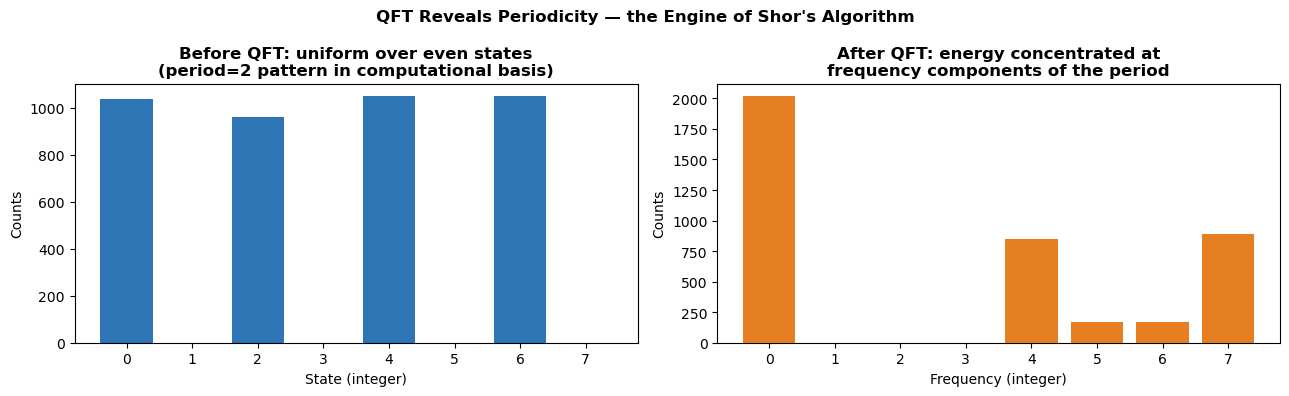

QFT transforms a periodic pattern in amplitude space
into a concentrated peak in frequency space.
This is exactly how Shor's algorithm finds the period r of a^x mod N.

Gate count scaling comparison:
    n qubits      N=2^n    QFT gates    Classical FFT
------------------------------------------------------
           3          8            6               24
           5         32           15              160
          10       1024           55            10240
          20    1048576          210         20971520
          50 1125899906842624         1275 56294995342131200


In [8]:
def qft(n):
    """Quantum Fourier Transform on n qubits."""
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)                          # Hadamard on qubit i
        for j in range(i+1, n):          # Controlled phase rotations
            angle = 2 * np.pi / (2 ** (j - i + 1))
            qc.cp(angle, j, i)           # Controlled-phase from qubit j to i
    # Swap qubits to get correct output ordering
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    return qc

def inverse_qft(n):
    """Inverse QFT — used in QPE and Shor's."""
    return qft(n).inverse()


# Show the circuit
n = 4
qft4 = qft(n)
print(f'QFT circuit for {n} qubits:')
print(qft4.draw(output='text'))
print(f'Gate count: {qft4.size()}')
print(f'Classical FFT of {2**n} points needs {2**n * n} operations')
print()

# --- Demo: QFT finds periodicity ---
# Prepare a state with period 2: |0> + |2> + |4> + |6> (for n=3)
# QFT should give a state peaked at frequencies 0 and 4
n_demo = 3
N = 2**n_demo

qc_period = QuantumCircuit(n_demo, n_demo)
# Manually prepare |0> + |2> + |4> + |6> (period=2)
# This is H on qubit 1 and 2, leave qubit 0 in |0>
qc_period.h(1)
qc_period.h(2)
# Append QFT
qc_period.compose(qft(n_demo), inplace=True)
qc_period.measure(range(n_demo), range(n_demo))

# Compare with direct measurement (no QFT)
qc_no_qft = QuantumCircuit(n_demo, n_demo)
qc_no_qft.h(1)
qc_no_qft.h(2)
qc_no_qft.measure(range(n_demo), range(n_demo))

counts_qft    = run(qc_period, shots=4096)
counts_no_qft = run(qc_no_qft, shots=4096)

# Convert to integer keys for plotting
def to_int_dict(counts, n):
    d = {int(k, 2): 0 for k in [format(i, f'0{n}b') for i in range(2**n)]}
    for k, v in counts.items():
        d[int(k, 2)] = v
    return d

d_qft    = to_int_dict(counts_qft,    n_demo)
d_no_qft = to_int_dict(counts_no_qft, n_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(list(d_no_qft.keys()), list(d_no_qft.values()), color='#2E75B6')
axes[0].set_title('Before QFT: uniform over even states\n(period=2 pattern in computational basis)', fontweight='bold')
axes[0].set_xlabel('State (integer)')
axes[0].set_ylabel('Counts')
axes[0].set_xticks(range(N))

axes[1].bar(list(d_qft.keys()), list(d_qft.values()), color='#E67E22')
axes[1].set_title('After QFT: energy concentrated at\nfrequency components of the period', fontweight='bold')
axes[1].set_xlabel('Frequency (integer)')
axes[1].set_ylabel('Counts')
axes[1].set_xticks(range(N))

plt.suptitle('QFT Reveals Periodicity — the Engine of Shor\'s Algorithm', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('QFT transforms a periodic pattern in amplitude space')
print('into a concentrated peak in frequency space.')
print('This is exactly how Shor\'s algorithm finds the period r of a^x mod N.')

# Gate count scaling
print()
print('Gate count scaling comparison:')
print(f'{"n qubits":>12} {"N=2^n":>10} {"QFT gates":>12} {"Classical FFT":>16}')
print('-' * 54)
for n_q in [3, 5, 10, 20, 50]:
    qft_gates = n_q * (n_q + 1) // 2
    fft_ops   = 2**n_q * n_q
    print(f'{n_q:>12} {2**n_q:>10} {qft_gates:>12} {fft_ops:>16}')

### What we see
- Before QFT: measurements uniformly distributed over all even states (period 2 in amplitude space)
- After QFT: measurements concentrated at specific frequency peaks — the periodic structure is **revealed**
- The gate count scaling shows why QFT is so powerful: 50 qubits needs only 1,275 gates versus $50 \times 2^{50} \approx 56$ trillion classical operations
- This exponential compression is why Shor's algorithm can factor large numbers efficiently

---
# 8. Bonus: Noisy Simulation — What Real Hardware Looks Like

Everything above used a perfect simulator. Real quantum hardware has:
- **Decoherence**: qubits lose their quantum state over time
- **Gate errors**: each gate has a small error probability
- **Readout errors**: measurement outcomes are occasionally flipped

Let's add noise to Bernstein-Vazirani and see how results degrade.

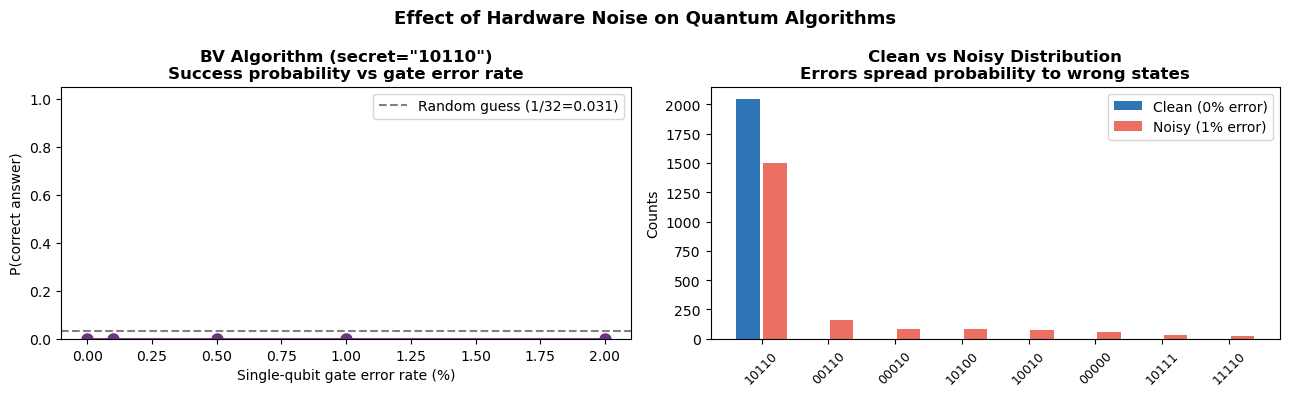

Success probability at different error rates:
  Gate error 0.0%: 0.000  
  Gate error 0.1%: 0.000  
  Gate error 0.5%: 0.000  
  Gate error 1.0%: 0.000  
  Gate error 2.0%: 0.000  

Key insight: even 1% gate error per gate, with ~10 gates in BV,
already causes noticeable degradation. This is why coherence time
and gate fidelity are so critical — and why circuit depth must be minimised.


In [9]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

def make_noise_model(gate_error_rate, readout_error_rate):
    """Build a simple depolarising noise model."""
    noise_model = NoiseModel()
    # Single-qubit gate error
    error_1q = depolarizing_error(gate_error_rate, 1)
    noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'ry', 'rz'])
    # Two-qubit gate error (usually worse)
    error_2q = depolarizing_error(gate_error_rate * 10, 2)
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    # Readout error
    ro_err = ReadoutError([[1 - readout_error_rate, readout_error_rate],
                           [readout_error_rate, 1 - readout_error_rate]])
    noise_model.add_all_qubit_readout_error(ro_err)
    return noise_model


secret = '10110'
qc_bv = bernstein_vazirani(secret)

error_rates = [0.0, 0.001, 0.005, 0.01, 0.02]
success_probs = []

for rate in error_rates:
    if rate == 0.0:
        counts = run(qc_bv, shots=2048)
    else:
        nm = make_noise_model(rate, rate)
        sim_noisy = AerSimulator(noise_model=nm)
        result = sim_noisy.run(qc_bv, shots=2048).result()
        counts = result.get_counts()
    # Correct answer (accounting for bit ordering)
    correct_answer = secret[::-1]  # Qiskit reversal
    success = counts.get(correct_answer, 0) / 2048
    success_probs.append(success)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Success probability vs error rate
axes[0].plot([r*100 for r in error_rates], success_probs, 'o-', color='#6C3483', linewidth=2, markersize=8)
axes[0].axhline(1/2**5, color='gray', ls='--', label=f'Random guess (1/{2**5}=0.031)')
axes[0].set_title(f'BV Algorithm (secret="{secret}")\nSuccess probability vs gate error rate', fontweight='bold')
axes[0].set_xlabel('Single-qubit gate error rate (%)')
axes[0].set_ylabel('P(correct answer)')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Distribution at 0% vs 1% error
nm_1pct = make_noise_model(0.01, 0.01)
sim_noisy = AerSimulator(noise_model=nm_1pct)
counts_noisy = sim_noisy.run(qc_bv, shots=2048).result().get_counts()
counts_clean = run(qc_bv, shots=2048)

# Top 8 states
top_noisy = dict(sorted(counts_noisy.items(), key=lambda x: -x[1])[:8])
top_clean = dict(sorted(counts_clean.items(), key=lambda x: -x[1])[:8])

x = np.arange(len(top_noisy))
axes[1].bar(x - 0.2, [top_clean.get(k,0) for k in top_noisy], 0.35, label='Clean (0% error)', color='#2E75B6')
axes[1].bar(x + 0.2, list(top_noisy.values()), 0.35, label='Noisy (1% error)', color='#E74C3C', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(top_noisy.keys()), rotation=45, fontsize=9)
axes[1].set_title('Clean vs Noisy Distribution\nErrors spread probability to wrong states', fontweight='bold')
axes[1].set_ylabel('Counts')
axes[1].legend()

plt.suptitle('Effect of Hardware Noise on Quantum Algorithms', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Success probability at different error rates:')
for rate, prob in zip(error_rates, success_probs):
    bar = '#' * int(prob * 40)
    print(f'  Gate error {rate*100:.1f}%: {prob:.3f}  {bar}')

print()
print('Key insight: even 1% gate error per gate, with ~10 gates in BV,')
print('already causes noticeable degradation. This is why coherence time')
print('and gate fidelity are so critical — and why circuit depth must be minimised.')

---
# Summary

| Algorithm | Key quantum resource | Speedup | Circuit depth | Practical value |
|-----------|---------------------|---------|---------------|-----------------|
| Superposition + interference | Superposition | — | 1–2 gates | Foundation |
| Bell state | Entanglement | — | 2 gates | Foundation, QKD |
| Deutsch-Jozsa | Interference | Exponential (queries) | Shallow | Benchmarking |
| Bernstein-Vazirani | Interference | Exponential (queries) | Shallow | Benchmarking, hardware test |
| Quantum Teleportation | Entanglement + classical | — | ~5 gates | Quantum networks |
| Grover's Search | Amplitude amplification | Quadratic | Medium | Unstructured search |
| QFT | Phase encoding + interference | Exponential | $O(n^2)$ | Subroutine for Shor's, QPE |

## The connecting thread

All of these algorithms share a common structure:

```
1. Prepare superposition     (H gates)           — explore all answers simultaneously
2. Encode problem            (Oracle/Phase gates) — mark or shift the target
3. Interfere                 (H gates again)      — constructive interference toward answer
4. Measure                   (Collapse)           — read out the amplified answer
```

**Interference is the key** — quantum algorithms work by constructively interfering toward the correct answer and destructively interfering away from wrong ones. This is what gives quantum computing its power, and it is something a classical computer fundamentally cannot do.

## Next steps

From here you can explore:
- **VQE**: variational quantum eigensolver for ground state energies
- **QAOA**: quantum approximate optimisation for combinatorial problems  
- **Quantum Phase Estimation**: exact eigenvalues using QFT as a subroutine
- **Shor's algorithm**: factoring using period finding and QFT
- **Error mitigation**: zero-noise extrapolation and probabilistic error cancellation